<a href="https://colab.research.google.com/github/sumaurya/master-data-research/blob/develop/EDA_and_Preprocessing_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

- read the raw data into a dataframe from merged_master_data.csv

In [70]:
# prompt: read the raw data into a dataframe from merged_master_data.csv

import pandas as pd
import warnings

# Ignore warnings
warnings.filterwarnings('ignore')

# Assuming merged_master_data.csv is in the current working directory
original_df = pd.read_csv('merged_master_data.csv')

- drop unwanted columns

In [71]:
# prompt: merge these list.. these are unwanted ciolumns.. drop them
# # skipped 'date' column for now
object_column_names = ['date', 'created_at', 'updated_at', 'annual_earning_date', 'balance_sheet_filing_date', 'cash_flow_filing_date',
                       'earning_history_date', 'exchange_code', 'income_statement_date', 'income_statement_filing_date',
                       'outstanding_shares_date', 'outstanding_shares_date_formatted', 'report_date', 'technical_master_data_sync_date', 'earning_trend_date']
int_column_names = ['id', 'hash_code_value', 'exchange', 'fund', 'vendor', 'vendor_api']

unwanted_columns = object_column_names + int_column_names
modified_df = original_df.drop(columns=unwanted_columns, errors='ignore')


print("Original DataFrame shape:", original_df.shape)
print("Modified DataFrame shape:", modified_df.shape)

Original DataFrame shape: (11057, 245)
Modified DataFrame shape: (11057, 224)


In [72]:
# prompt: - create a function in which for each column except 'date' column, create column_name+ "_missing" and set it to True if the values was missing/NaN and False if value is present. return the modified dataframe

def create_missing_indicator_columns(df):
  """
  Creates new columns indicating missing values for each column except 'date'.

  Args:
    df: The input pandas DataFrame.

  Returns:
    The modified DataFrame with new missing indicator columns.
  """

  for column in df.columns:
    if column != 'date':
      df[column + '_missing'] = df[column].isnull()

  return df

# Apply the function to the modified_df
modified_df = create_missing_indicator_columns(modified_df)
print("Modified DataFrame shape:", modified_df.shape)

Modified DataFrame shape: (11057, 448)


- split the dataset into train and test

In [73]:
# prompt: I haven't decided any target variable.. I wanto split the data set as it is into train and test
# - split the dataset into train and test

from sklearn.model_selection import train_test_split

# Split the dataset into train and test sets (e.g., 80% train, 20% test)
train_df, test_df = train_test_split(modified_df, test_size=0.2, random_state=42)

print("Train DataFrame shape:", train_df.shape)
print("Test DataFrame shape:", test_df.shape)

Train DataFrame shape: (8845, 448)
Test DataFrame shape: (2212, 448)


- create a function in which remove duplicate rows from train dataset. return the modified dataframe

In [74]:
# prompt: - create a function in which remove duplicate rows from train dataset. return the modified dataframe

def remove_duplicate_rows(df):
  """
  Removes duplicate rows from a DataFrame.

  Args:
    df: The input pandas DataFrame.

  Returns:
    The modified DataFrame with duplicate rows removed.
  """
  df = df.drop_duplicates()
  return df

# Example usage:
train_df = remove_duplicate_rows(train_df)
print("Train DataFrame shape after removing duplicates:", train_df.shape)

Train DataFrame shape after removing duplicates: (8845, 448)


- create a function in which. and return the modified dataframe
    - for each numeric column in train dataset :
        - apply mutation and fill NaN with median of the same numeric column. if all values in the column are NaN and median can't be calculated, use median 0. keep the non-null values as it is.
        - also store the calculated median should be stored in median_mutation.csv as column_name,meadian_value

In [75]:
# prompt: - create a function in which. and return the modified dataframe
#     - for each numeric column in train dataset :
#         - apply mutation and fill NaN with median of the same numeric column. if all values in the column are NaN and median can't be calculated, use median 0. keep the non-null values as it is.
#         - also store the calculated median should be stored in median_mutation.csv as column_name,meadian_value

def fill_na_with_median_and_store(df):
  """
  Fills NaN values in numeric columns with the median of the column,
  stores the calculated medians in a CSV file, and returns the modified DataFrame.

  Args:
    df: The input pandas DataFrame.

  Returns:
    The modified DataFrame with NaN values filled.
  """
  median_values = {}
  for column in df.select_dtypes(include=['number']):
    median = df[column].median()
    if pd.isnull(median):
      median = 0
    df[column] = df[column].fillna(median)
    median_values[column] = median

  # Store the median values in median_mutation.csv
  median_df = pd.DataFrame(list(median_values.items()), columns=['column_name', 'median_value'])
  median_df.to_csv('median_mutation.csv', index=False)

  return df

# Apply the function to the train_df
train_df = fill_na_with_median_and_store(train_df)
print("Train DataFrame shape after filling NaN with median:", train_df.shape)

Train DataFrame shape after filling NaN with median: (8845, 448)


- create a function in which. and return the modified dataframe
    - for each numeric column in train dataset :
        - check if the distribution is normal using Shapiro-Wilk Test or not and do following action :
            - if normal distribution,
                - if value in current cell is 2 standard deviation away from the mean, then consider it an outlier and replace with a median
                - store (column_name, 2 standard deviation value, median) in outlier_replacement_normal.csv
            - if not normal distribution,
                - do following
                lower_percentile = df['column'].quantile(0.25)
                upper_percentile = df['column'].quantile(0.75)
                df.loc[df['column'] < lower_bound, 'column'] = lower_percentile
                df.loc[df['column'] > upper_bound, 'column'] = upper_percentile
                - store (column_name, lower_percentile value, upper_percentile value) in outlier_replacement_non_normal.csv

In [76]:
# prompt: - create a function in which. and return the modified dataframe
#     - for each numeric column in train dataset :
#         - check if the distribution is normal using Shapiro-Wilk Test or not and do following action :
#             - if normal distribution,
#                 - if value in current cell is 2 standard deviation away from the mean, then consider it an outlier and replace with a median
#                 - store (column_name, 2 standard deviation value, median) in outlier_replacement_normal.csv
#             - if not normal distribution,
#                 - do following
#                 lower_percentile = df['column'].quantile(0.25)
#                 upper_percentile = df['column'].quantile(0.75)
#                 df.loc[df['column'] < lower_bound, 'column'] = lower_percentile
#                 df.loc[df['column'] > upper_bound, 'column'] = upper_percentile
#                 - store (column_name, lower_percentile value, upper_percentile value) in outlier_replacement_non_normal.csv

from scipy.stats import shapiro

def handle_outliers(df):
  """
  Handles outliers in numeric columns based on their distribution (normal or not).

  Args:
    df: The input pandas DataFrame.

  Returns:
    The modified DataFrame with outliers handled.
  """
  outlier_replacement_normal = []
  outlier_replacement_non_normal = []

  for column in df.select_dtypes(include=['number']):
    try:
      # Check for normality using Shapiro-Wilk Test
      stat, p = shapiro(df[column].dropna())
      if p > 0.05:  # Distribution is considered normal
        mean = df[column].mean()
        std = df[column].std()
        upper_bound = mean + 2 * std
        lower_bound = mean - 2 * std
        median = df[column].median()

        df.loc[(df[column] > upper_bound) | (df[column] < lower_bound), column] = median
        outlier_replacement_normal.append((column, 2 * std, median))

      else:  # Distribution is not normal
        lower_percentile = df[column].quantile(0.25)
        upper_percentile = df[column].quantile(0.75)
        df.loc[df[column] < lower_percentile, column] = lower_percentile
        df.loc[df[column] > upper_percentile, column] = upper_percentile
        outlier_replacement_non_normal.append((column, lower_percentile, upper_percentile))
    except Exception as e:
        print(f"Error processing column {column}: {e}")

  # Store outlier replacement information in CSV files
  pd.DataFrame(outlier_replacement_normal, columns=['column_name', '2_std_value', 'median']).to_csv(
      'outlier_replacement_normal.csv', index=False)
  pd.DataFrame(outlier_replacement_non_normal, columns=['column_name', 'lower_percentile', 'upper_percentile']).to_csv(
      'outlier_replacement_non_normal.csv', index=False)

  return df


# Apply the function to the train_df
train_df = handle_outliers(train_df)
print("Train DataFrame shape after handling outliers:", train_df.shape)

Train DataFrame shape after handling outliers: (8845, 448)


- create a function in which. and return the modified dataframe
    - for each column_name in outlier_replacement_normal.csv
        - apply Standardization
    - for each column_name in outlier_replacement_non_normal.csv
        - apply Normalization
    - store the scaler objects in seperate files using joblib

In [77]:
# prompt: - create a function in which. and return the modified dataframe
#     - for each column_name in outlier_replacement_normal.csv
#         - apply Standardization
#     - for each column_name in outlier_replacement_non_normal.csv
#         - apply Normalization
# do it like
# scaler = StandardScaler()
# scaler.fit(train_data[['feature1', 'feature2', ...]])
# not one column at a time

from sklearn.preprocessing import StandardScaler, MinMaxScaler
import joblib

def apply_scaling(df):
  """
  Applies standardization to columns specified in 'outlier_replacement_normal.csv'
  and normalization to columns specified in 'outlier_replacement_non_normal.csv'.

  Args:
    df: The input pandas DataFrame.

  Returns:
    The modified DataFrame with scaling applied.
  """
  try:
    normal_columns = pd.read_csv('outlier_replacement_normal.csv')['column_name'].tolist()
    non_normal_columns = pd.read_csv('outlier_replacement_non_normal.csv')['column_name'].tolist()

    if normal_columns:
      scaler = StandardScaler()
      df[normal_columns] = scaler.fit_transform(df[normal_columns])
      joblib.dump(scaler, 'scaler_normal.joblib')

    if non_normal_columns:
      scaler = MinMaxScaler()
      df[non_normal_columns] = scaler.fit_transform(df[non_normal_columns])
      joblib.dump(scaler, 'scaler_non_normal.joblib')

    return df

  except FileNotFoundError:
    print("Error: 'outlier_replacement_normal.csv' or 'outlier_replacement_non_normal.csv' not found.")
    return df


# Apply the function to the train_df
train_df = apply_scaling(train_df)
print("Train DataFrame shape after scaling:", train_df.shape)

Train DataFrame shape after scaling: (8845, 448)


- apply one-hot encoding

In [78]:
def apply_one_hot_encoding(df):
    # Identify categorical columns
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

    # Identify boolean columns and convert to integers
    boolean_cols = df.select_dtypes(include=['bool']).columns.tolist()
    for col in boolean_cols:
        df[col] = df[col].astype(int)

    # Combine categorical and boolean columns for one-hot encoding
    all_cols_to_encode = categorical_cols + boolean_cols
    print(all_cols_to_encode)

    # Apply one-hot encoding to categorical columns
    df_encoded = pd.get_dummies(df, columns=all_cols_to_encode, drop_first=True)

    return df_encoded

train_df = apply_one_hot_encoding(train_df)
print(train_df.shape)
train_df.head()

['balance_sheet_currency_symbol', 'before_after_market', 'cash_flow_currency_symbol', 'cash_flow_duration', 'currency_symbol', 'earning_history_currency', 'five_percent_reached_in_one_day', 'fund_code', 'income_statement_duration', 'outstanding_shares_duration', 'period', 'accounts_payable_missing', 'accumulated_amortization_missing', 'accumulated_depreciation_missing', 'accumulated_other_comprehensive_income_missing', 'additional_paid_in_capital_missing', 'adjusted_close_missing', 'adjusted_working_capital_missing', 'adx_missing', 'annual_earning_eps_actual_missing', 'assets_missing', 'atr_missing', 'avgvol_missing', 'avgvolccy_missing', 'balance_sheet_currency_symbol_missing', 'balance_sheet_interest_expense_missing', 'balance_sheet_operating_income_missing', 'before_after_market_missing', 'begin_period_cash_flow_missing', 'beta_missing', 'capital_expenditures_missing', 'capital_lease_obligations_missing', 'capital_stock_missing', 'capital_surpluse_missing', 'cash_missing', 'cash_and

,accounts_payable,accumulated_amortization,accumulated_depreciation,accumulated_other_comprehensive_income,additional_paid_in_capital,adjusted_close,adjusted_working_capital,adx,annual_earning_eps_actual,assets,...,total_liabilities_missing_1,total_operating_expenses_missing_1,total_other_income_expense_net_missing_1,total_permanent_equity_missing_1,total_revenue_missing_1,total_stockholder_equity_missing_1,treasury_stock_missing_1,uband_missing_1,volatility_missing_1,wma_missing_1
6695,1.000000,0.0,0.0,0.604752,0.0,1.000000,0.0,0.174658,1.000000,0.0,...,False,False,False,False,False,False,False,False,False,False
4065,0.000000,0.0,0.0,0.000000,0.0,0.010551,0.0,0.000000,0.102190,0.0,...,False,False,False,True,False,False,True,False,False,False
7997,0.073948,0.0,0.0,1.000000,0.0,0.193435,0.0,1.000000,0.021898,0.0,...,False,False,False,True,False,False,True,False,False,False
8784,0.000000,0.0,0.0,0.912100,0.0,0.001758,0.0,0.405251,0.102190,0.0,...,False,False,False,True,False,False,True,False,False,False
7277,0.660895,0.0,0.0,1.000000,0.0,0.607855,0.0,0.123288,0.357664,0.0,...,False,False,False,False,False,False,False,False,False,False


- Reduce Dimensions(remove multicolinearity). Apply PCA.

In [79]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def find_ideal_component_count(train_df, target_variables) :
  # Assuming X_scaled is your standardized data
  X_scaled = train_df.drop(columns=target_variables)
  pca = PCA().fit(X_scaled)

  # Get explained variance ratio
  explained_variance = pca.explained_variance_ratio_

  # Filter for values greater than 0
  positive_variance = explained_variance[explained_variance > 0.005]

  # Count components with explained variance greater than 0
  count_positive_components = len(positive_variance)

  # Print count of components
  print(f"Count of components where explained_variance_ratio > 0: {count_positive_components}")

  # Plotting the positive explained variance ratio
  plt.figure(figsize=(8, 5))
  plt.bar(range(1, len(positive_variance) + 1), positive_variance)
  plt.title('PCA Explained Variance Ratio (Only Positive Values)')
  plt.xlabel('Principal Component')
  plt.ylabel('Explained Variance Ratio')
  plt.xticks(range(1, len(positive_variance) + 1))
  plt.show()

Count of components where explained_variance_ratio > 0: 17


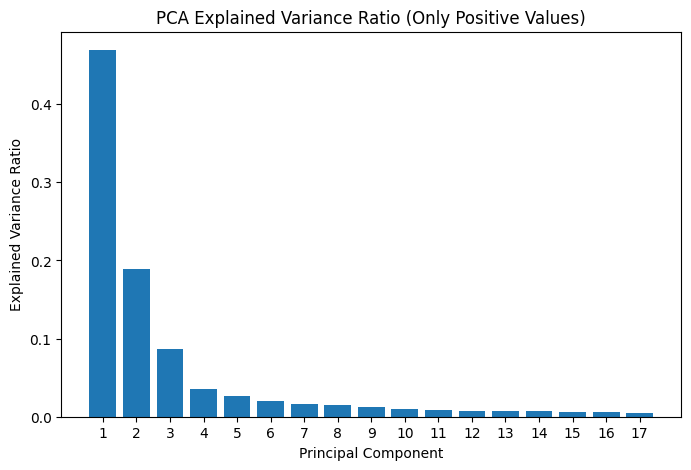

In [80]:
target_variables = ['five_percent_reached_in_one_day_t', 'days_taken_for_5_percent', 'percentage_change_in_next_open']
find_ideal_component_count(train_df, target_variables)

In [81]:
def apply_pca(df, n_components=None):
  # Fit PCA
    pca = PCA(n_components=n_components)
    pca.fit(df)

    # Transform the data
    transformed_data = pca.transform(df)

    # Get explained variance ratio
    explained_variance_ratio = pca.explained_variance_ratio_

    return pd.DataFrame(transformed_data), explained_variance_ratio

# Apply PCA
transformed_df, variance_ratio = apply_pca(train_df, n_components=17)

# Print results
print("\nExplained Variance Ratio:")
print(variance_ratio)
print("Transformed Data:")
transformed_df.head()



Explained Variance Ratio:
[0.46557303 0.18730959 0.08641431 0.0346299  0.02664052 0.02041977
 0.01561662 0.01505842 0.01260563 0.00979334 0.00866389 0.00729907
 0.00705436 0.00667602 0.00589053 0.00558405 0.00527135]
Transformed Data:


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,-7.432621,2.322882,1.069441,-0.472075,-1.074342,0.571427,0.611664,0.848860,-0.394443,-0.820293,-0.506043,-0.379707,-1.255406,-0.751940,-0.034809,-0.358263,-0.693026
1,2.876144,-1.475267,1.975254,1.865716,1.099604,1.132140,1.335526,0.540608,0.659393,0.071043,0.323444,-0.036197,0.350810,0.391347,0.361712,-0.214957,-0.285955
2,0.584957,-3.062576,-1.563458,-1.974606,0.700644,1.023634,-0.116842,0.212376,0.631221,0.774701,0.875511,-0.752499,0.153903,-0.726741,-0.913742,0.108045,0.666098
3,2.436538,-2.364329,1.724913,0.897567,0.258315,0.645924,1.065693,-0.548998,-0.406171,0.100640,-0.340463,-0.266157,0.419156,-0.158241,-0.020012,0.005886,0.561545
4,-3.415383,-1.308648,-3.565792,0.181766,0.380647,1.001427,0.226671,-0.450680,1.248962,-0.502973,-0.960649,-1.200496,-0.203203,0.188738,0.490879,-0.232354,0.017055
